This [file](https://dls.hevs.ch/ts/files/penicillin-data-01.csv) contains a subset of the data simulated by this [Industrial-Scale Penicillin Simulator](http://www.industrialpenicillinsimulation.com/).

1. Read the description of the data set provided on the simulator’s website.

2. Extract the data from the file in a DataFrame format.

In [2]:
import pandas as pd # We will work with pandas for data management.

df = pd.read_csv('https://dls.hevs.ch/ts/files/penicillin-data-01.csv') # Load the CSV file containing the data.

In [3]:
df.head() # Show the first rows of the DataFrame.

,Time (h),Batch ID,Penicillin concentration(P:g/L),pH(pH:pH),Temperature(T:K)
0,0.2,1,1.017800e-25,6.4472,298.22
1,0.4,1,1.000000e-03,6.4932,298.17
2,0.6,1,9.993400e-04,6.5425,298.14
3,0.8,1,9.987400e-04,6.5753,298.11
4,1.0,1,9.982100e-04,6.5825,298.09


In [35]:
df.describe() # Computes basic statistics for each column.

,Time (h),Batch ID,Penicillin concentration(P:g/L),pH(pH:pH),Temperature(T:K)
count,113935.000000,113935.000000,1.139350e+05,113935.000000,113935.000000
mean,114.750656,50.402466,1.433395e+01,6.496565,298.026489
std,66.990504,28.862140,9.932453e+00,0.065676,0.197513
min,0.200000,1.000000,3.694700e-26,5.395700,296.840000
25%,57.000000,26.000000,5.531250e+00,6.493200,297.950000
50%,114.000000,50.000000,1.438000e+01,6.500900,297.990000
75%,171.000000,76.000000,2.268750e+01,6.508600,298.040000
max,290.000000,100.000000,3.618300e+01,6.766400,302.180000


3. What is the time step? What is the recording time?

The time step can be determined by looking at the output of 'head()'. 
However, to be more systematic, let us check the time difference between each consecutive measurements. 

In [39]:
import matplotlib.pyplot as plt

dt = df['Time (h)'].iloc[1:-1].values - df['Time (h)'].iloc[0:-2].values # Take the difference between the time values from 1 to the end and the time values from 0 to then end-1.

A histogram of these time differences shows us that the vast majority of the time steps are very close to 0.2.

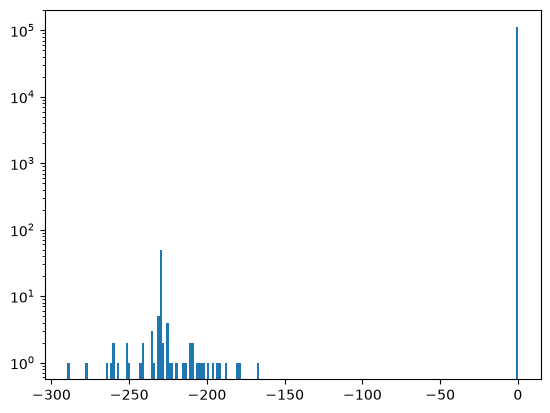

In [40]:
fig,ax = plt.subplots()
ax.hist(dt,200)
ax.set_yscale('log')
plt.show()

Let us count how many times the value 0.2 appears in 'dt'.
We tolerate a deviation of $10^{-5}$ from 0.2, because of floating point accuracy (none of the values stored is exactly 0.2).

In [41]:
import numpy as np

n = np.sum(np.abs(dt - 0.2) < 1e-5)
n

np.int64(113834)

The vast majority of the time steps are of length 0.2 hours, i.e., 12 minutes. 
All other time steps correspond to the starting of a new batch.

The recording time may be different for each batch. 
Let us extract the time value of the last time step of each batch.

Max: 290.0
Min: 167.0
Mean: 227.87


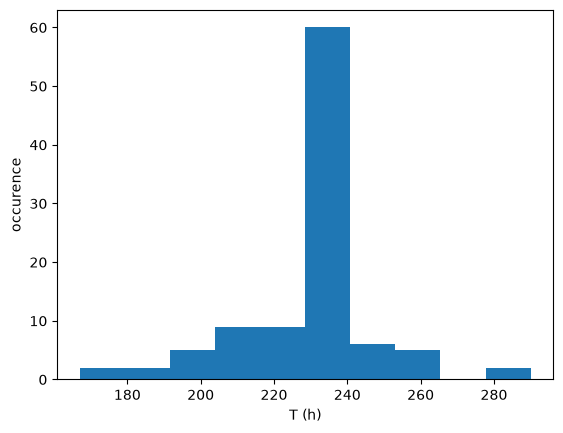

In [63]:
Ts = np.array([df[df['Batch ID'] == i]['Time (h)'].max() for i in range(1,101)]) # For each batch ID from 1 to 100, put the max() in an array.

print(f'Max: {Ts.max()}')
print(f'Min: {Ts.min()}')
print(f'Mean: {Ts.mean()}')

fig,ax = plt.subplots()
ax.hist(Ts)
ax.set_xlabel('T (h)')
ax.set_ylabel('occurence')

plt.show()


4. Choose one batch and one measured quantity, and plot the time series.

In [64]:
df13 = df[df['Batch ID'] == 13].loc[:,['Time (h)','pH(pH:pH)']] # Extract the Time and pH values of batch nr 13.
df13.head()

,Time (h),pH(pH:pH)
13745,0.2,6.4517
13746,0.4,6.4910
13747,0.6,6.5377
13748,0.8,6.5682
13749,1.0,6.5737


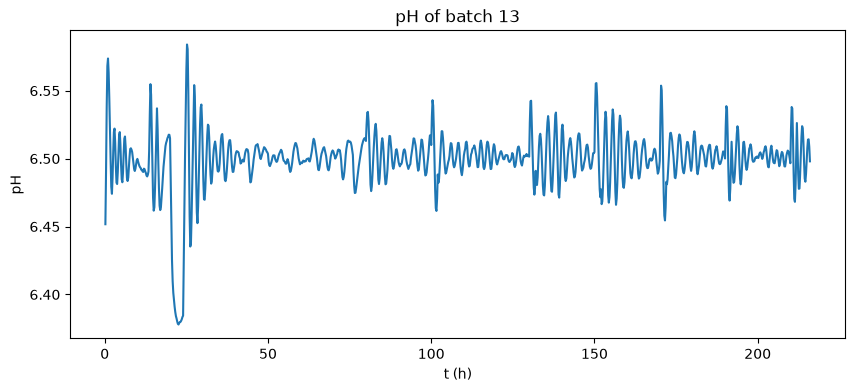

In [65]:
# Plot the pH vs time for batch 13
fig, ax = plt.subplots(figsize=(10,4))

ax.plot(df13['Time (h)'],df13['pH(pH:pH)'])
ax.set_xlabel('t (h)')
ax.set_ylabel('pH')
ax.set_title('pH of batch 13')

plt.show()

5. Resample the time series with time step of one hour and represent it on top of the original time series. How did you choose the value of the resampled time series?

In [66]:
# Build the list of average pH over each bloc of 5 time steps (1 hour).
list_13_h = [df13['pH(pH:pH)'].iloc[range(i,i+5)].mean() for i in range(0,len(df13['pH(pH:pH)']),5)]

# Convert into a DataFrame
df13_h = pd.DataFrame({'Time (h)': range(len(list_13_h)), 'pH': list_13_h})
df13_h.head()

,Time (h),pH
0,0,6.52446
1,1,6.52126
2,2,6.50136
3,3,6.49196
4,4,6.50946
